# Relatório completo — ativações e quantização no Mac M4

## Resumo

- **Ativações com augmentation 0,5:** 27 treinos, nove datasets × ReLU/Sigmoid/Softmax; 100 épocas cada.
- **Treinamento para quantização:** 18 treinos, nove datasets × FP32/FP16; 100 épocas cada.
- **INT8 PTQ:** nove conversões e avaliações LiteRT após o treino, não novos treinamentos.

O snapshot contém **45 treinamentos, 4.500 épocas, 54 avaliações finais e 1.002 linhas de métricas por classe**. Cada condição usa seed 42; portanto, as diferenças são descritivas e não estimam variabilidade entre seeds.

O uso de CPU/GPU/RAM vem de telemetria agregada a cada cinco segundos. O Mac M4 usa memória unificada, então a memória GPU é compartilhada pelo SoC, não VRAM dedicada. Não há medição de potência/energia.

## Método e limites

O notebook usa os CSVs compactos em analysis_reports/activation_quantization_2026-09-30/data/. Eles foram exportados dos manifests, históricos, métricas de teste e resumos de hardware dos diretórios locais outputs/ com scripts/export_activation_quantization_evidence.py. O snapshot exclui checkpoints, previsões/logits, amostras brutas de telemetria e caminhos absolutos.

As campanhas usam seed 42, normalização unit_interval, balance_mode all_raw, augmentation extra_fraction=0,5 e 100 épocas. Ativações e quantização foram executadas como campanhas separadas; o perfil de quantização tem 18 treinos FP32/FP16 e nove medições INT8 PTQ. Macro-F1 é a métrica de comparação principal. Médias entre datasets são simples e não ponderadas; datasets diferem em tamanho, classes e dificuldade. Não há múltiplas seeds nem teste de significância.

A telemetria INT8 não é comparável à dos treinos e não entra nos gráficos de hardware. Os percentuais refletem amostras observadas durante as execuções; CPU do processo pode passar de 100% por uso multicore.

## 1. Carregar e validar o pacote de evidências

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

data_rel = Path("analysis_reports/activation_quantization_2026-09-30/data")
root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / data_rel / "runs.csv").is_file()), None)
if root is None:
    raise FileNotFoundError(f"Snapshot não encontrado a partir de {Path.cwd()}")
data_dir = root / data_rel
runs = pd.read_csv(data_dir / "runs.csv")
epochs = pd.read_csv(data_dir / "epoch_history.csv")
per_class = pd.read_csv(data_dir / "per_class_metrics.csv")

for col in ["test_accuracy", "test_balanced_accuracy", "test_macro_f1", "test_macro_ovr_auc",
            "training_seconds", "mean_epoch_seconds", "gpu_mean_percent", "gpu_p95_percent",
            "gpu_memory_p95_gib", "process_rss_p95_gib", "ram_p95_percent"]:
    runs[col] = pd.to_numeric(runs[col], errors="coerce")
for col in ["epoch", "val_macro_f1", "epoch_seconds", "train_examples_per_second"]:
    epochs[col] = pd.to_numeric(epochs[col], errors="coerce")

train = runs.query("stage == 'training'").copy()
activation = train.query("campaign == 'activation'").copy()
quant_train = train.query("campaign == 'quantization'").copy()
ptq = runs.query("stage == 'post_training_quantization_evaluation'").copy()

assert (len(activation), len(quant_train), len(ptq), len(epochs)) == (27, 18, 9, 4500)
assert train.status.eq("completed").all() and train.epochs_completed.eq(100).all()
assert not runs.source_ref.astype(str).str.startswith("/").any()
print(f"Fonte: {data_dir.relative_to(root)}")
print(f"{len(train)} treinos concluídos; {len(epochs):,} pontos de época; {len(ptq)} avaliações INT8 PTQ")
display(runs.groupby(["campaign", "stage", "status"], dropna=False).size().rename("runs").reset_index())

Fonte: analysis_reports/activation_quantization_2026-09-30/data
45 treinos concluídos; 4,500 pontos de época; 9 avaliações INT8 PTQ


,campaign,stage,status,runs
0,activation,training,completed,27
1,quantization,post_training_quantization_evaluation,completed,9
2,quantization,training,completed,18


## 2. Todos os treinamentos: métricas de teste e duração

In [2]:
labels = {
    "mnist": "MNIST", "fashion_mnist": "Fashion-MNIST", "kmnist": "KMNIST",
    "emnist_balanced": "EMNIST balanced", "cifar10": "CIFAR-10",
    "cifar100_coarse": "CIFAR-100 coarse", "svhn": "SVHN", "gtsrb": "GTSRB", "fer2013": "FER2013",
}
order = list(labels)
colors_act = {"relu": "#315A78", "sigmoid": "#C49A24", "softmax": "#B65C63"}
colors_quant = {"fp32": "#315A78", "fp16": "#C49A24", "int8_ptq": "#D8763C"}
activation["dataset_label"] = activation.dataset.map(labels)
activation_table = activation[[
    "dataset_label", "condition", "epochs_completed", "best_epoch", "test_samples",
    "test_accuracy", "test_balanced_accuracy", "test_macro_f1", "test_macro_ovr_auc",
    "mean_epoch_seconds", "training_seconds",
]].sort_values(["dataset_label", "condition"]).copy()
for c in ["test_accuracy", "test_balanced_accuracy", "test_macro_f1", "test_macro_ovr_auc"]:
    activation_table[c] = (100 * activation_table[c]).round(2)
activation_table["training_hours"] = (activation_table.pop("training_seconds") / 3600).round(2)
activation_table["seconds_per_epoch"] = activation_table.pop("mean_epoch_seconds").round(1)
display(activation_table.rename(columns={
    "dataset_label": "Dataset", "condition": "Ativação", "epochs_completed": "Épocas",
    "best_epoch": "Melhor época", "test_samples": "N teste", "test_accuracy": "Acurácia (%)",
    "test_balanced_accuracy": "Acc. balanceada (%)", "test_macro_f1": "Macro-F1 (%)",
    "test_macro_ovr_auc": "Macro-AUC OVR (%)", "training_hours": "Treino (h)",
    "seconds_per_epoch": "s/época",
}).reset_index(drop=True))

activation_winners = activation.loc[activation.groupby("dataset").test_macro_f1.idxmax(),
                                    ["dataset", "condition", "test_macro_f1"]].sort_values("dataset")
winner_counts = activation_winners.condition.value_counts()
print("Vitórias por Macro-F1:", {k.upper(): int(winner_counts.get(k, 0)) for k in colors_act})
softmax_f1 = activation.loc[activation.condition.eq("softmax"), "test_macro_f1"]
print(f"Faixa Softmax: {softmax_f1.min():.2%}–{softmax_f1.max():.2%}")

,Dataset,Ativação,Épocas,Melhor época,N teste,Acurácia (%),Acc. balanceada (%),Macro-F1 (%),Macro-AUC OVR (%),Treino (h),s/época
0,CIFAR-10,relu,100.0,33.0,9000,56.64,56.64,56.45,89.87,3.20,115.1
1,CIFAR-10,sigmoid,100.0,99.0,9000,63.67,63.67,63.90,93.83,3.95,142.0
2,CIFAR-10,softmax,100.0,1.0,9000,10.00,10.00,1.82,50.00,3.16,113.7
3,CIFAR-100 coarse,relu,100.0,54.0,9000,30.32,30.32,29.98,79.20,3.17,114.2
4,CIFAR-100 coarse,sigmoid,100.0,100.0,9000,36.61,36.61,35.02,85.52,3.95,142.1
5,CIFAR-100 coarse,softmax,100.0,1.0,9000,5.00,5.00,0.48,50.00,3.21,115.7
6,EMNIST balanced,relu,100.0,77.0,19740,84.86,84.86,84.42,99.41,3.81,236.8
7,EMNIST balanced,sigmoid,100.0,78.0,19740,85.28,85.28,84.93,99.61,8.44,303.8
8,EMNIST balanced,softmax,100.0,1.0,19740,2.13,2.13,0.09,50.00,6.80,244.9
9,FER2013,relu,100.0,38.0,5382,40.32,33.33,27.47,73.22,1.68,60.3


Vitórias por Macro-F1: {'RELU': 1, 'SIGMOID': 8, 'SOFTMAX': 0}
Faixa Softmax: 0.09%–5.72%


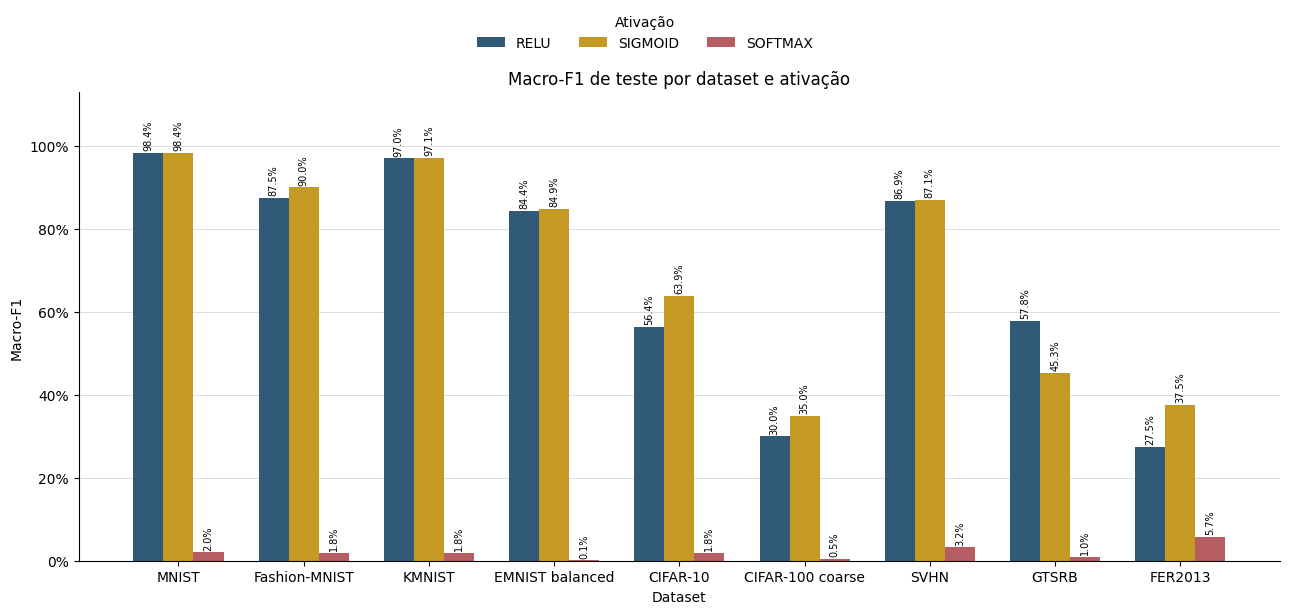

Sigmoid venceu oito datasets; ReLU venceu GTSRB. Softmax teve resultado muito baixo neste protocolo. Uma seed limita a generalização.


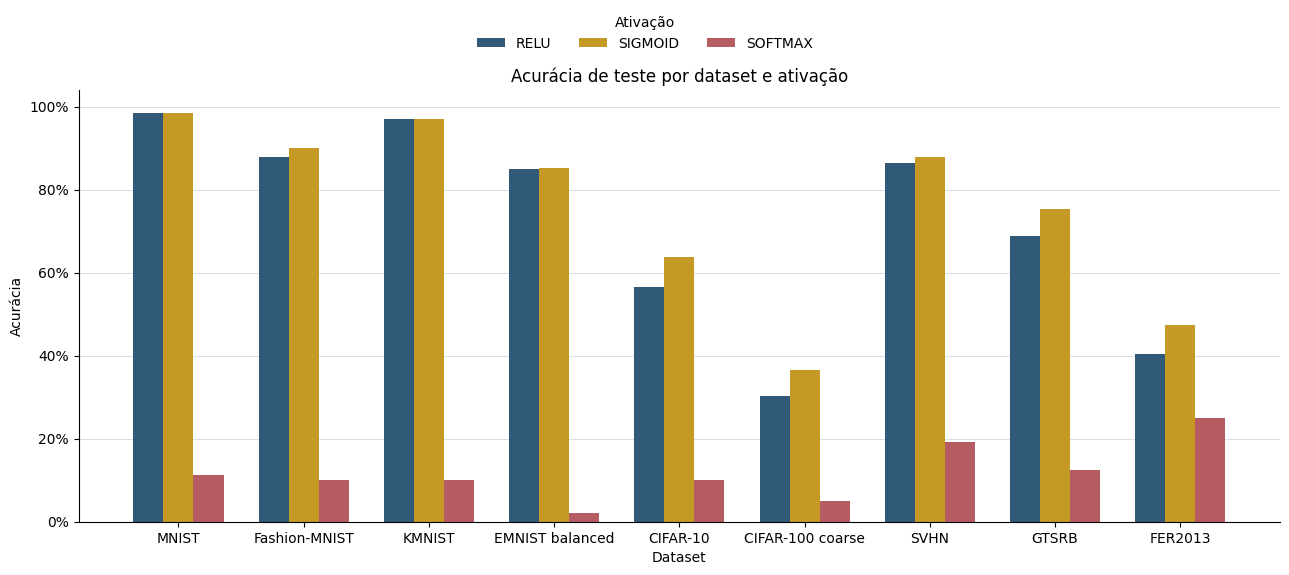

In [3]:
dataset_order = ["mnist", "fashion_mnist", "kmnist", "emnist_balanced", "cifar10",
                 "cifar100_coarse", "svhn", "gtsrb", "fer2013"]
dataset_x = np.arange(len(dataset_order))
act_pivot = activation.pivot(index="dataset", columns="condition", values="test_macro_f1").reindex(dataset_order)
width = 0.24
fig, ax = plt.subplots(figsize=(13, 6.2))
for i, condition in enumerate(["relu", "sigmoid", "softmax"]):
    values = act_pivot[condition].to_numpy()
    bars = ax.bar(dataset_x + (i - 1) * width, values, width, label=condition.upper(),
                  color=colors_act[condition])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], padding=2, fontsize=7, rotation=90)
ax.set(title="Macro-F1 de teste por dataset e ativação", ylabel="Macro-F1", xlabel="Dataset")
ax.set_xticks(dataset_x, [labels[d] for d in dataset_order])
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 1.13)
ax.grid(axis="y", color="#D9DEE3", linewidth=0.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, title="Ativação", frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 0.995))
fig.tight_layout(rect=[0, 0, 1, 0.91]); plt.show()
print("Sigmoid venceu oito datasets; ReLU venceu GTSRB. Softmax teve resultado muito baixo neste protocolo. Uma seed limita a generalização.")

accuracy_pivot = activation.pivot(index="dataset", columns="condition", values="test_accuracy").reindex(dataset_order)
fig, ax = plt.subplots(figsize=(13, 5.8))
for i, condition in enumerate(["relu", "sigmoid", "softmax"]):
    ax.bar(dataset_x + (i - 1) * width, accuracy_pivot[condition], width,
           label=condition.upper(), color=colors_act[condition])
ax.set(title="Acurácia de teste por dataset e ativação", ylabel="Acurácia", xlabel="Dataset")
ax.set_xticks(dataset_x, [labels[d] for d in dataset_order])
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0, 1.04)
ax.grid(axis="y", color="#D9DEE3", linewidth=0.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, title="Ativação", frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 0.995))
fig.tight_layout(rect=[0, 0, 1, 0.91]); plt.show()

## 3. Comparação FP32/FP16 e avaliação INT8 PTQ

,Dataset,Perfil,Etapa,Épocas,Melhor época,N teste,Acurácia (%),Macro-F1 (%),Treino (h),s/época
0,CIFAR-10,fp16,training,100.0,91.0,9000,70.24,70.18,3.80,136.91
1,CIFAR-10,fp32,training,100.0,98.0,9000,69.81,69.78,2.37,85.27
2,CIFAR-10,int8_ptq,post_training_quantization_evaluation,NaN,NaN,9000,68.73,68.44,NaN,NaN
3,CIFAR-100 coarse,fp16,training,100.0,97.0,9000,44.81,45.26,3.93,141.34
4,CIFAR-100 coarse,fp32,training,100.0,92.0,9000,44.48,44.63,1.45,89.75
5,CIFAR-100 coarse,int8_ptq,post_training_quantization_evaluation,NaN,NaN,9000,41.57,41.50,NaN,NaN
6,EMNIST balanced,fp16,training,100.0,80.0,19740,87.17,87.01,2.72,287.76
7,EMNIST balanced,fp32,training,100.0,90.0,19740,87.31,87.14,5.01,180.46
8,EMNIST balanced,int8_ptq,post_training_quantization_evaluation,NaN,NaN,19740,86.91,86.72,NaN,NaN
9,FER2013,fp16,training,100.0,51.0,5382,48.20,44.14,2.04,73.49


,Dataset,FP16 − FP32 (p.p.),INT8 PTQ − FP32 (p.p.)
0,MNIST,-0.12,-0.62
1,Fashion-MNIST,0.03,-19.15
2,KMNIST,0.27,-1.65
3,EMNIST balanced,-0.13,-0.43
4,CIFAR-10,0.40,-1.33
5,CIFAR-100 coarse,0.63,-3.12
6,SVHN,-0.31,-0.48
7,GTSRB,0.41,-18.43
8,FER2013,0.46,-5.88


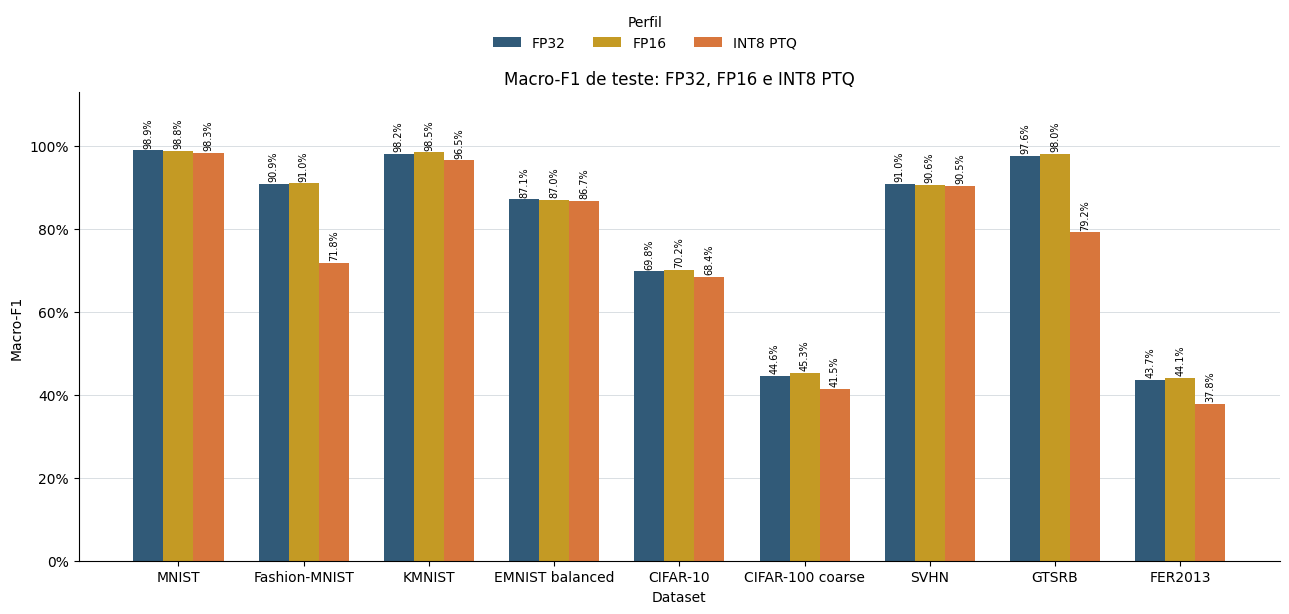

INT8 PTQ é uma avaliação pós-conversão, não um treino INT8/QAT. Diferenças são p.p. no mesmo dataset e não têm inferência estatística.


In [4]:
quant_all = pd.concat([
    quant_train[["dataset", "condition", "stage", "epochs_completed", "best_epoch", "test_samples",
                 "test_accuracy", "test_macro_f1", "training_seconds", "mean_epoch_seconds"]],
    ptq[["dataset", "condition", "stage", "test_samples", "test_accuracy", "test_macro_f1"]]
        .assign(epochs_completed=np.nan, best_epoch=np.nan, training_seconds=np.nan, mean_epoch_seconds=np.nan),
], ignore_index=True)
quant_all["dataset_label"] = quant_all.dataset.map(labels)
quant_all["Macro-F1 (%)"] = 100 * quant_all.test_macro_f1
quant_all["Acurácia (%)"] = 100 * quant_all.test_accuracy
quant_all["Treino (h)"] = quant_all.training_seconds / 3600
quant_all["s/época"] = quant_all.mean_epoch_seconds
display(quant_all[["dataset_label", "condition", "stage", "epochs_completed", "best_epoch",
                   "test_samples", "Acurácia (%)", "Macro-F1 (%)", "Treino (h)", "s/época"]]
        .sort_values(["dataset_label", "condition"]).round(2).rename(columns={
            "dataset_label": "Dataset", "condition": "Perfil", "stage": "Etapa",
            "epochs_completed": "Épocas", "best_epoch": "Melhor época", "test_samples": "N teste",
        }).reset_index(drop=True))

quant_pivot = quant_all.pivot(index="dataset", columns="condition", values="test_macro_f1").reindex(dataset_order)
deltas = pd.DataFrame({
    "Dataset": [labels[d] for d in dataset_order],
    "FP16 − FP32 (p.p.)": 100 * (quant_pivot.fp16 - quant_pivot.fp32).to_numpy(),
    "INT8 PTQ − FP32 (p.p.)": 100 * (quant_pivot.int8_ptq - quant_pivot.fp32).to_numpy(),
})
display(deltas.round(2))

fig, ax = plt.subplots(figsize=(13, 6.2))
for i, condition in enumerate(["fp32", "fp16", "int8_ptq"]):
    values = quant_pivot[condition].to_numpy()
    bars = ax.bar(dataset_x + (i - 1) * width, values, width,
                  label={"fp32": "FP32", "fp16": "FP16", "int8_ptq": "INT8 PTQ"}[condition],
                  color=colors_quant[condition])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], padding=2, fontsize=7, rotation=90)
ax.set(title="Macro-F1 de teste: FP32, FP16 e INT8 PTQ", ylabel="Macro-F1", xlabel="Dataset")
ax.set_xticks(dataset_x, [labels[d] for d in dataset_order])
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0, 1.13)
ax.grid(axis="y", color="#D9DEE3", linewidth=0.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, title="Perfil", frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 0.995))
fig.tight_layout(rect=[0, 0, 1, 0.91]); plt.show()
print("INT8 PTQ é uma avaliação pós-conversão, não um treino INT8/QAT. Diferenças são p.p. no mesmo dataset e não têm inferência estatística.")

## 4. Curvas de validação nas 100 épocas

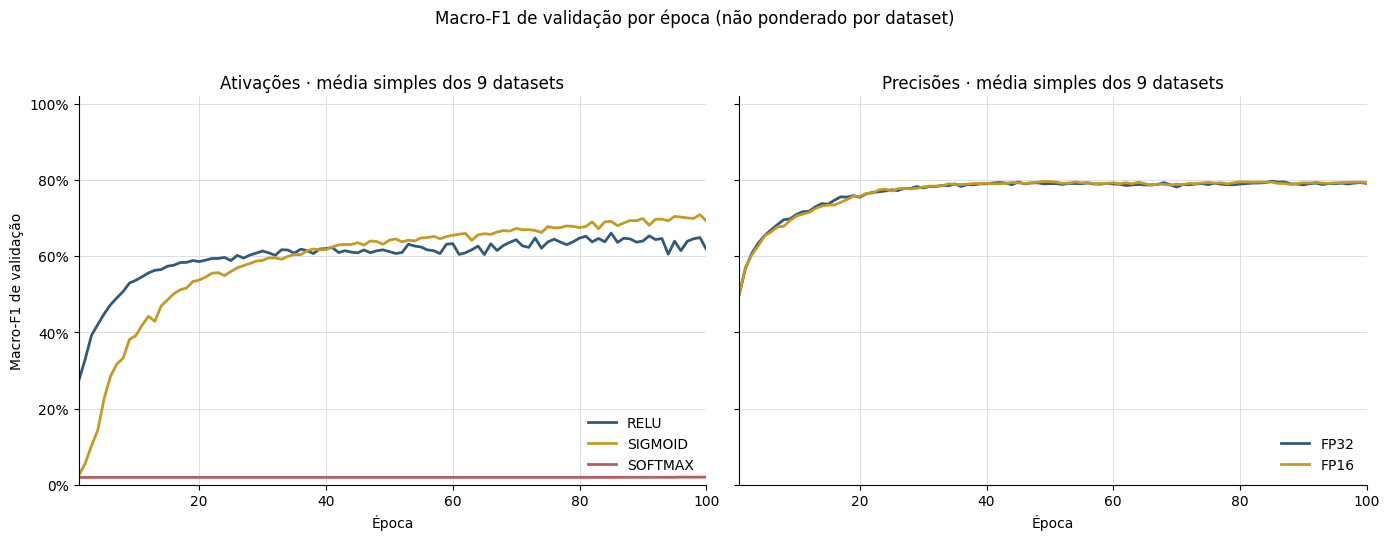

As médias são resumos descritivos de tarefas diferentes. O checkpoint de cada run é selecionado pelo melhor Macro-F1 de validação.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for condition in ["relu", "sigmoid", "softmax"]:
    curve = (epochs.query("campaign == 'activation' and condition == @condition")
             .groupby("epoch").val_macro_f1.mean())
    axes[0].plot(curve.index, curve.values, label=condition.upper(),
                 color=colors_act[condition], linewidth=2)
for condition in ["fp32", "fp16"]:
    curve = (epochs.query("campaign == 'quantization' and condition == @condition")
             .groupby("epoch").val_macro_f1.mean())
    axes[1].plot(curve.index, curve.values, label=condition.upper(),
                 color=colors_quant[condition], linewidth=2)
axes[0].set_title("Ativações · média simples dos 9 datasets")
axes[1].set_title("Precisões · média simples dos 9 datasets")
for ax in axes:
    ax.set_xlabel("Época"); ax.set_xlim(1, 100); ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(color="#D9DEE3", linewidth=0.7); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, loc="lower right")
axes[0].set_ylabel("Macro-F1 de validação")
fig.suptitle("Macro-F1 de validação por época (não ponderado por dataset)", y=1.03)
fig.tight_layout(); plt.show()
print("As médias são resumos descritivos de tarefas diferentes. O checkpoint de cada run é selecionado pelo melhor Macro-F1 de validação.")

## 5. Uso observado de hardware

In [6]:
group_name = {
    "relu": "Ativação · ReLU", "sigmoid": "Ativação · Sigmoid", "softmax": "Ativação · Softmax",
    "fp32": "Quantização · FP32", "fp16": "Quantização · FP16",
}
train["hardware_group"] = train.condition.map(group_name)
hardware_summary = train.groupby(["campaign", "condition", "hardware_group"], as_index=False).agg(
    runs=("run_id", "count"), backend=("gpu_backend", "first"), gpu=("gpu_name", "first"),
    host_cpu_mean_median=("cpu_mean_percent", "median"),
    process_cpu_mean_median=("process_cpu_mean_percent", "median"),
    gpu_mean_median=("gpu_mean_percent", "median"), gpu_p95_median=("gpu_p95_percent", "median"),
    gpu_memory_p95_median_gib=("gpu_memory_p95_gib", "median"),
    process_rss_p95_median_gib=("process_rss_p95_gib", "median"),
    ram_p95_median_percent=("ram_p95_percent", "median"), ram_max_peak_percent=("ram_max_percent", "max"),
    training_hours_median=("training_seconds", lambda s: s.median() / 3600),
)
display(hardware_summary.drop(columns=["campaign", "condition"]).round(2).rename(columns={
    "hardware_group": "Grupo", "runs": "Runs", "backend": "Backend", "gpu": "GPU",
    "host_cpu_mean_median": "CPU host média, mediana (%)",
    "process_cpu_mean_median": "CPU processo média, mediana (%)",
    "gpu_mean_median": "GPU média, mediana (%)", "gpu_p95_median": "GPU p95, mediana (%)",
    "gpu_memory_p95_median_gib": "Memória GPU p95, mediana (GiB)",
    "process_rss_p95_median_gib": "RSS processo p95, mediana (GiB)",
    "ram_p95_median_percent": "RAM p95, mediana (%)", "ram_max_peak_percent": "Maior pico RAM (%)",
    "training_hours_median": "Treino mediano (h)",
}))
print("Backend(s):", sorted(train.gpu_backend.dropna().unique()), "| GPU(s):", sorted(train.gpu_name.dropna().unique()))
print("RAM física registrada: 16 GiB. Memória GPU unificada/compartilhada. CPU de processo pode exceder 100% com uso multicore.")

,Grupo,Runs,Backend,GPU,"CPU host média, mediana (%)","CPU processo média, mediana (%)","GPU média, mediana (%)","GPU p95, mediana (%)","Memória GPU p95, mediana (GiB)","RSS processo p95, mediana (GiB)","RAM p95, mediana (%)",Maior pico RAM (%),Treino mediano (h)
0,Ativação · ReLU,9,apple-metal-ioreg,Apple M4,19.88,85.05,91.87,97.0,1.12,3.11,77.2,85.9,3.20
1,Ativação · Sigmoid,9,apple-metal-ioreg,Apple M4,18.10,87.72,80.90,87.0,1.02,3.14,77.3,84.4,3.95
2,Ativação · Softmax,9,apple-metal-ioreg,Apple M4,18.52,85.54,92.22,96.0,1.16,3.09,75.9,84.8,3.23
3,Quantização · FP16,9,apple-metal-ioreg,Apple M4,17.83,84.38,82.27,88.0,1.50,3.30,73.4,86.3,3.80
4,Quantização · FP32,9,apple-metal-ioreg,Apple M4,20.40,92.66,91.69,95.0,1.08,3.76,73.9,89.2,2.29


Backend(s): ['apple-metal-ioreg'] | GPU(s): ['Apple M4']
RAM física registrada: 16 GiB. Memória GPU unificada/compartilhada. CPU de processo pode exceder 100% com uso multicore.


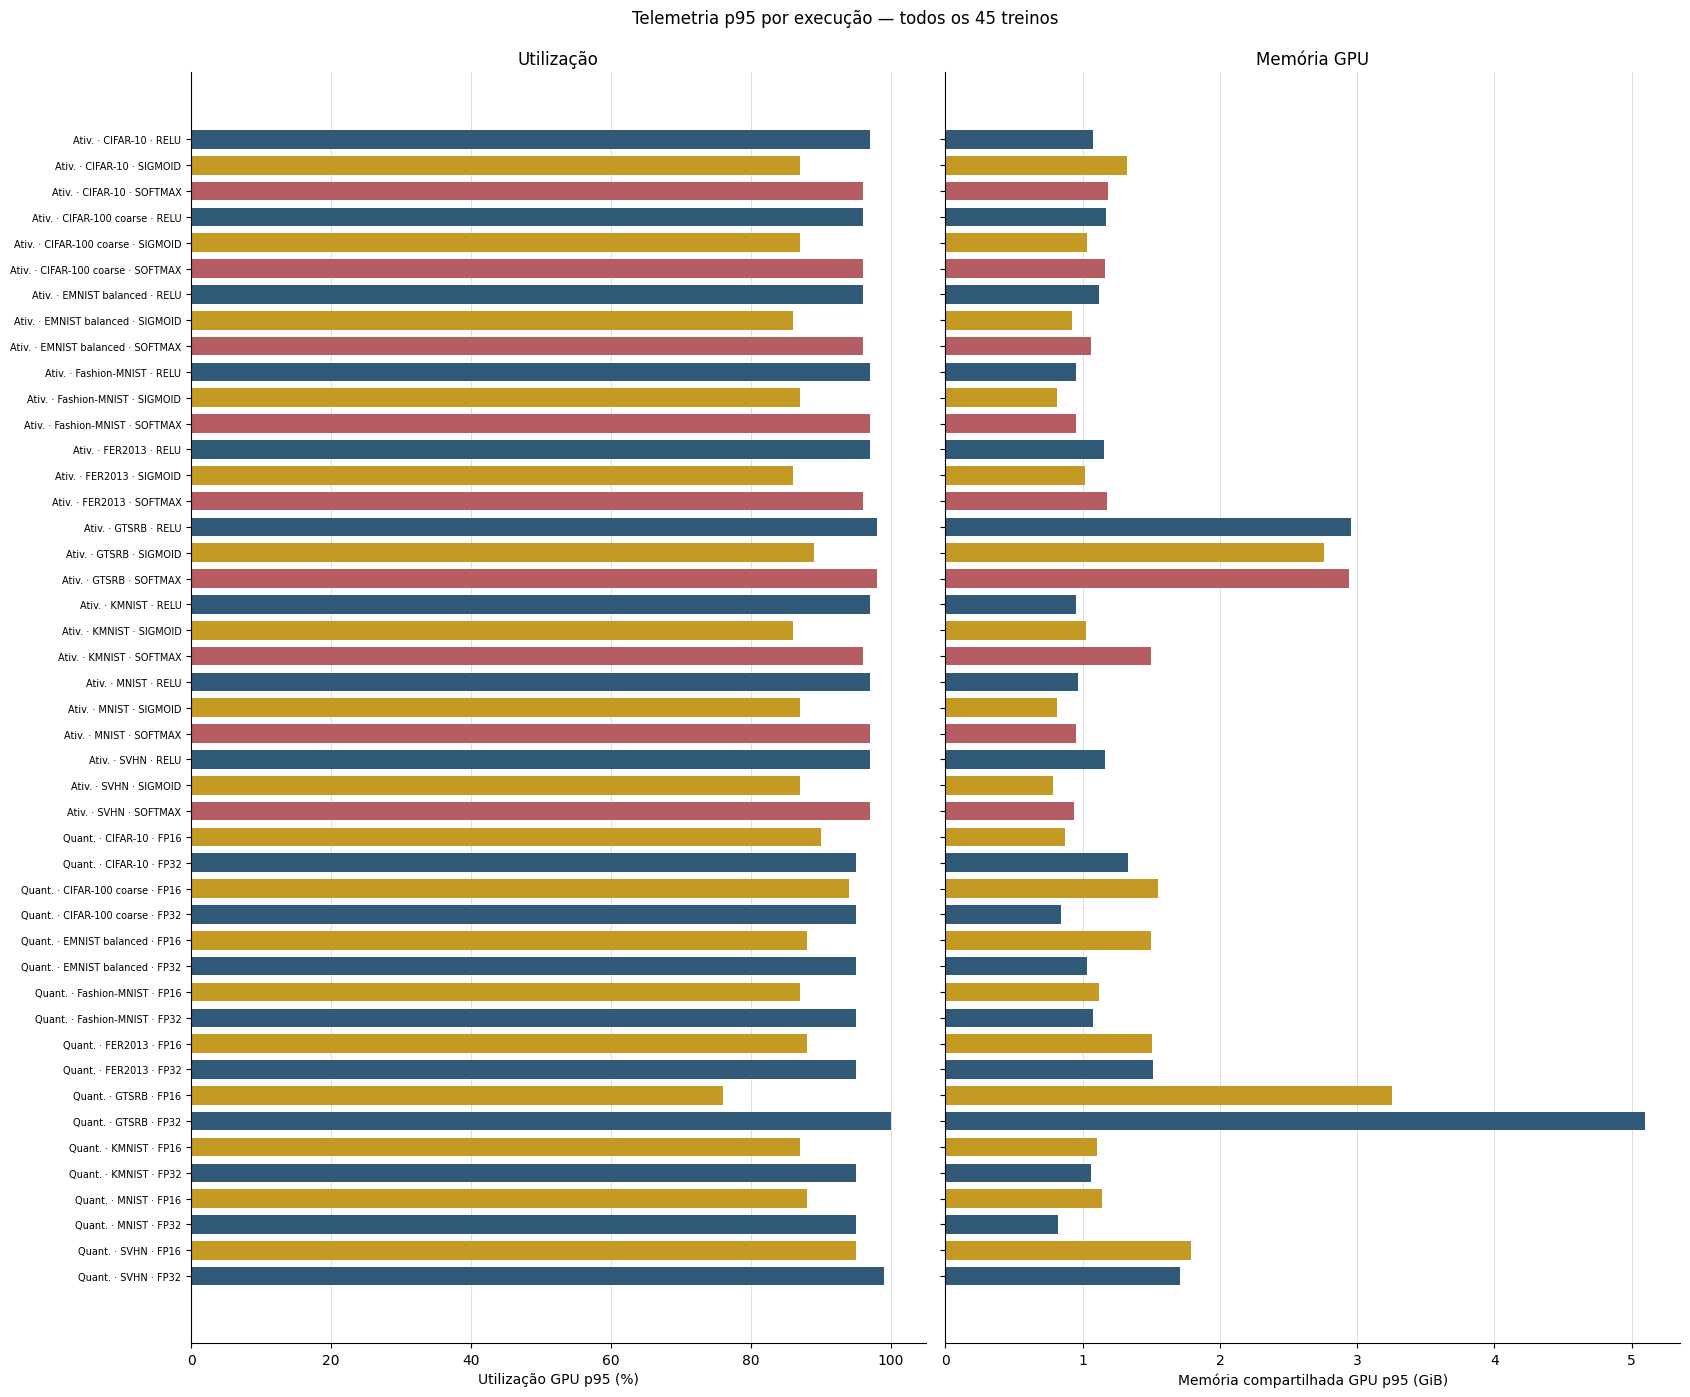

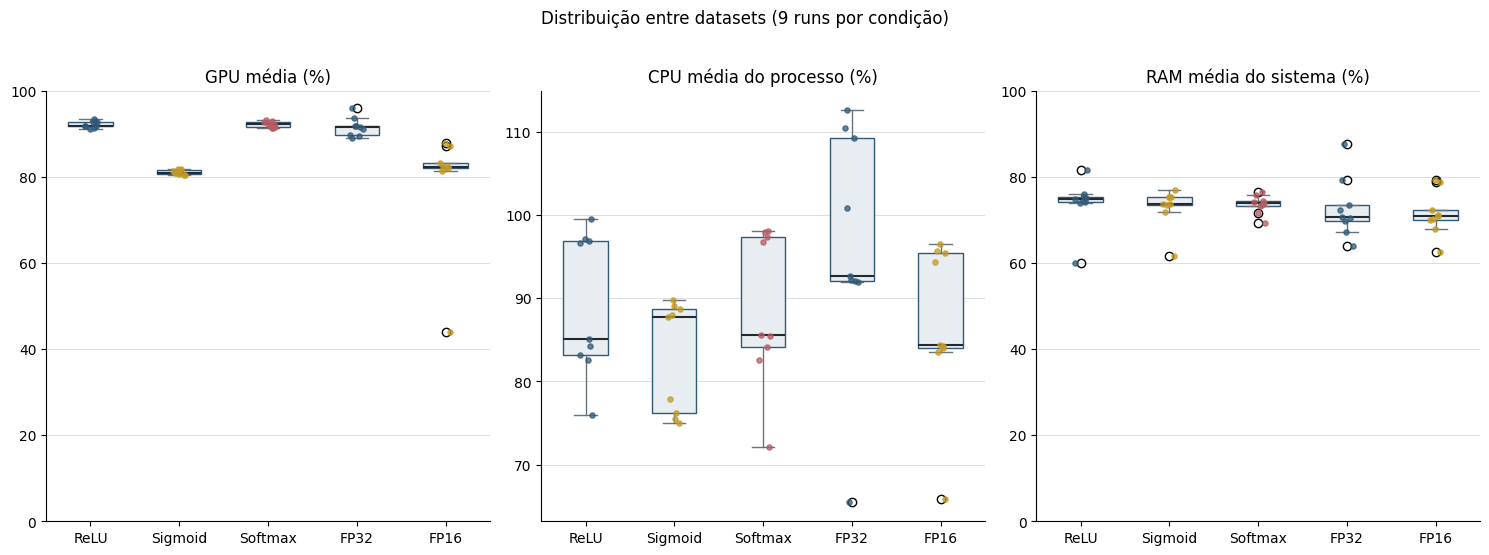

Telemetria resume amostras durante a execução; p95 não significa uso contínuo nesse nível. Energia/potência não foi medida.


In [7]:
color_by_condition = {
    "relu": colors_act["relu"], "sigmoid": colors_act["sigmoid"], "softmax": colors_act["softmax"],
    "fp32": colors_quant["fp32"], "fp16": colors_quant["fp16"],
}
run_label = (train.campaign.map({"activation": "Ativ.", "quantization": "Quant."})
             + " · " + train.dataset.map(labels) + " · " + train.condition.str.upper())
hardware_runs = train.assign(run_label=run_label).sort_values(["campaign", "dataset", "condition"]).reset_index(drop=True)
bar_colors = hardware_runs.condition.map(color_by_condition)
pos = np.arange(len(hardware_runs))
fig, axes = plt.subplots(1, 2, figsize=(17, 14), sharey=True)
axes[0].barh(pos, hardware_runs.gpu_p95_percent, color=bar_colors, height=0.72)
axes[0].set_xlim(0, 105); axes[0].set_xlabel("Utilização GPU p95 (%)"); axes[0].set_title("Utilização")
axes[1].barh(pos, hardware_runs.gpu_memory_p95_gib, color=bar_colors, height=0.72)
axes[1].set_xlabel("Memória compartilhada GPU p95 (GiB)"); axes[1].set_title("Memória GPU")
axes[0].set_yticks(pos, hardware_runs.run_label, fontsize=7); axes[0].invert_yaxis()
for ax in axes:
    ax.grid(axis="x", color="#D9DEE3", linewidth=0.7); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Telemetria p95 por execução — todos os 45 treinos", y=0.995)
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
groups = ["relu", "sigmoid", "softmax", "fp32", "fp16"]
specs = [
    ("gpu_mean_percent", "GPU média (%)", (0, 100)),
    ("process_cpu_mean_percent", "CPU média do processo (%)", None),
    ("ram_mean_percent", "RAM média do sistema (%)", (0, 100)),
]
for ax, (metric, title, limits) in zip(axes, specs):
    data = [train.loc[train.condition.eq(key), metric].dropna().to_numpy() for key in groups]
    ax.boxplot(data, tick_labels=["ReLU", "Sigmoid", "Softmax", "FP32", "FP16"],
        patch_artist=True, boxprops={"facecolor": "#E8EDF1", "color": "#315A78"},
        medianprops={"color": "#24292E", "linewidth": 1.5},
        whiskerprops={"color": "#67727C"}, capprops={"color": "#67727C"})
    rng = np.random.default_rng(42)
    for x, key in enumerate(groups, start=1):
        vals = train.loc[train.condition.eq(key), metric].dropna().to_numpy()
        ax.scatter(x + rng.uniform(-0.08, 0.08, len(vals)), vals, s=14,
                   color=color_by_condition[key], alpha=0.75, zorder=3)
    ax.set_title(title); ax.grid(axis="y", color="#D9DEE3", linewidth=0.7)
    ax.set_axisbelow(True); ax.spines[["top", "right"]].set_visible(False)
    if limits: ax.set_ylim(*limits)
fig.suptitle("Distribuição entre datasets (9 runs por condição)", y=1.02)
fig.tight_layout(); plt.show()
print("Telemetria resume amostras durante a execução; p95 não significa uso contínuo nesse nível. Energia/potência não foi medida.")

## 6. Métricas por classe e encerramento

In [8]:
weakest = (per_class.query("stage == 'training'").sort_values("f1")
           .groupby(["campaign", "dataset", "condition"], as_index=False).first())
weakest["dataset_label"] = weakest.dataset.map(labels)
weakest["f1_percent"] = 100 * weakest.f1
display(weakest[["campaign", "dataset_label", "condition", "class_name", "f1_percent", "support"]]
        .sort_values(["campaign", "dataset_label", "condition"]).round(2).rename(columns={
            "campaign": "Campanha", "dataset_label": "Dataset", "condition": "Condição",
            "class_name": "Menor F1 por classe", "f1_percent": "F1 (%)", "support": "Suporte teste",
        }).reset_index(drop=True))

print("per_class_metrics.csv guarda precision, recall, F1 e suporte por classe para 45 treinos e 9 avaliações INT8 PTQ.")
print("runs.csv contém um registro por execução, incluindo resumos de hardware. epoch_history.csv contém 100 épocas por treino.")
print("As campanhas têm uma seed, portanto rankings e diferenças devem ser tratados como observações desta rodada, não como efeitos generalizáveis.")

,Campanha,Dataset,Condição,Menor F1 por classe,F1 (%),Suporte teste
0,activation,CIFAR-10,relu,cat,24.62,900
1,activation,CIFAR-10,sigmoid,cat,41.53,900
2,activation,CIFAR-10,softmax,horse,0.00,900
3,activation,CIFAR-100 coarse,relu,non-insect_invertebrates,0.00,450
4,activation,CIFAR-100 coarse,sigmoid,reptiles,4.32,450
5,activation,CIFAR-100 coarse,softmax,vehicles_2,0.00,450
6,activation,EMNIST balanced,relu,21,43.04,420
7,activation,EMNIST balanced,sigmoid,21,36.76,420
8,activation,EMNIST balanced,softmax,23,0.00,420
9,activation,FER2013,relu,angry,0.00,743


per_class_metrics.csv guarda precision, recall, F1 e suporte por classe para 45 treinos e 9 avaliações INT8 PTQ.
runs.csv contém um registro por execução, incluindo resumos de hardware. epoch_history.csv contém 100 épocas por treino.
As campanhas têm uma seed, portanto rankings e diferenças devem ser tratados como observações desta rodada, não como efeitos generalizáveis.
